# Project Title: Predicting Bike-Sharing Demand: A Weather-Driven Analysis for Capital Bikeshare

Fall24 SI618 Group 17

School of Information, University of Michigan

## Team Members
* Yidan Chang (yidanydc)
* Zhuxin Wu (zhuxinwu)
* Shangqing Wei (weishq)

# Part II: Analysis

## Descriptive Analysis

In [180]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset and drop the columns `start_lat`, `start_lng`, `end_lat`, `end_lng` which are not used in current analysis
# the dataset combined with datasets `Daily rent data`, `Station list` and `Usage frequency`
df_rent = pd.read_csv('detail_frequency.csv').drop(columns=['ride_id','start_lat','start_lng','end_lat','end_lng']).reset_index(drop=True)

In [181]:
df_rent.head()

,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,member_casual,started_day,pickup_counts,dropoff_counts
0,docked_bike,2023-05-12 18:57:59,2023-05-12 19:17:50,3rd & Tingey St SE,31634,8th & F St NE,31631,casual,2023-05-12,50.0,54.0
1,classic_bike,2023-05-23 07:55:29,2023-05-23 08:11:12,Clarendon Blvd & Pierce St,31016,15th & L St NW,31276,member,2023-05-23,14.0,45.0
2,electric_bike,2023-05-05 17:27:10,2023-05-05 17:40:17,South Capitol St and Southern Ave SE,31830,Tanger Outlets,32415,member,2023-05-05,2.0,6.0
3,classic_bike,2023-05-09 11:22:05,2023-05-09 11:35:11,11th & O St NW,31286,19th St & Pennsylvania Ave NW,31100,member,2023-05-09,53.0,17.0
4,classic_bike,2023-05-06 10:24:09,2023-05-06 10:35:13,11th & O St NW,31286,16th & Harvard St NW,31135,casual,2023-05-06,67.0,56.0


In [182]:
df_rent['started_at'] = pd.to_datetime(df_rent['started_at'], format="%Y-%m-%d %H:%M:%S", errors='coerce')
df_rent['ended_at'] = pd.to_datetime(df_rent['ended_at'], format="%Y-%m-%d %H:%M:%S", errors='coerce')
df_rent['duration'] = (df_rent['ended_at'] - df_rent['started_at']).dt.total_seconds() 
df_rent['started_day'] = pd.to_datetime(df_rent['started_day'])
df_rent.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009164 entries, 0 to 4009163
Data columns (total 12 columns):
 #   Column              Dtype         
---  ------              -----         
 0   rideable_type       object        
 1   started_at          datetime64[ns]
 2   ended_at            datetime64[ns]
 3   start_station_name  object        
 4   start_station_id    int64         
 5   end_station_name    object        
 6   end_station_id      int64         
 7   member_casual       object        
 8   started_day         datetime64[ns]
 9   pickup_counts       float64       
 10  dropoff_counts      float64       
 11  duration            float64       
dtypes: datetime64[ns](3), float64(3), int64(2), object(4)
memory usage: 367.1+ MB


In [183]:
df_weather = pd.read_csv('weather_frequency.csv', usecols=['date', 'temp', 'icon'])
df_weather['date'] = pd.to_datetime(df_weather['date'])
df_weather = df_weather.drop_duplicates().reset_index(drop=True)
df_weather.info()
weather = df_weather[['date', 'temp', 'icon', 'temp']].copy()
weather['date'] = pd.to_datetime(weather['date'])
weather.rename(columns={'icon': 'weather'}, inplace=True)
weather

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    367 non-null    datetime64[ns]
 1   temp    367 non-null    float64       
 2   icon    367 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 8.7+ KB


,date,temp,weather,temp
0,2023-05-01,13.7,rain,13.7
1,2023-05-02,11.9,cloudy,11.9
2,2023-05-03,11.0,rain,11.0
3,2023-05-04,12.7,partly-cloudy-day,12.7
4,2023-05-05,15.0,partly-cloudy-day,15.0
...,...,...,...,...
362,2024-04-27,13.2,rain,13.2
363,2024-04-28,19.5,partly-cloudy-day,19.5
364,2024-04-29,24.0,partly-cloudy-day,24.0
365,2024-04-30,23.3,rain,23.3


In [184]:
df = df_rent.merge(df_weather, left_on='started_day', right_on='date', how='left').drop(columns=['date'])
df = df.drop(columns=['started_day']).reset_index(drop=True)

In [198]:
rides_per_day = pd.DataFrame(df['started_at'].dt.date.value_counts().sort_index().reset_index())
rides_per_day.columns = ['date','rides_counts']
rides_per_day['date'] = pd.to_datetime(rides_per_day['date'])
rides_per_day = rides_per_day.merge(weather, left_on='date', right_on='date', how='left')
rides_per_day['rides_counts'] = rides_per_day['rides_counts'].astype(int)
rides_per_day = rides_per_day.loc[:, ~rides_per_day.columns.duplicated()]

In [186]:
# Calculate statistics for relevant features
numeric_features = ['pickup_counts', 'dropoff_counts', 'duration', 'temp']
statistics = []

# Function to calculate descriptive statistics for a feature
def descriptive_analysis(df, feature):
    mean_value = df[feature].mean().round(2)
    median_value = df[feature].median()
    mode_value = df[feature].mode()[0]
    range_value = df[feature].max() - df[feature].min()
    variance_value = df[feature].var()
    std_dev_value = df[feature].std().round(2)
    min_value = df[feature].min()
    max_value = df[feature].max()
    percentile_25 = df[feature].quantile(0.25)
    percentile_75 = df[feature].quantile(0.75)
    return [feature, mean_value, median_value, mode_value, range_value, variance_value, std_dev_value, min_value, percentile_25, percentile_75, max_value]

rides_per_day_descriptive = descriptive_analysis(rides_per_day, 'rides_counts')
for feature in numeric_features:
    statistics.append(descriptive_analysis(df, feature))

statistics.insert(0, rides_per_day_descriptive)

# Create a DataFrame for the statistics
stats_df = pd.DataFrame(statistics, columns=['Feature', 'Mean', 'Median', 'Mode', 'Range', 'Variance', 'Standard Deviation', 'Min', '25%', '75%', 'Max'])
stats_df

,Feature,Mean,Median,Mode,Range,Variance,Standard Deviation,Min,25%,75%,Max
0,rides_counts,10954.00,11751.0,7326.0,16008.0,1.137915e+07,3373.30,1737.0,8633.25,13601.0,17745.0
1,pickup_counts,50.03,43.0,37.0,374.0,1.313720e+03,36.25,1.0,24.00,68.0,375.0
2,dropoff_counts,50.40,44.0,43.0,373.0,1.339005e+03,36.59,0.0,24.00,68.0,373.0
3,duration,1050.32,628.0,298.0,2943356.0,1.733992e+07,4164.12,-4077.0,366.00,1087.0,2939279.0
4,temp,17.33,18.6,23.0,35.0,5.777028e+01,7.60,-5.0,11.40,23.7,30.0


### Overall Descriptive Analysis Summary

1. **rides_counts**:
   - The average daily ride count is **10,954**, with a median of **11,751**. The mode is **7,326**, indicating this value occurred most frequently.
   - The **range** of ride counts is **16,008** (min: **1,737**, max: **17,745**), with a **standard deviation** of **3,373.3**, suggesting a high level of fluctuation in daily ride counts.

2. **pickup_counts & dropoff_counts**:
   - Both features have similar statistics: average **~50**, median **~44**, and mode **~43**.
   - The **range** is **374** for pickups and **373** for dropoffs, indicating substantial variation, with a **standard deviation** of **~36**, showing moderate variability across different days.

3. **duration (in seconds)**:
   - The average duration is **1,050.32** (seconds), with a median of **628**. The mode is **298**.
   - There is a significant **range** of **2,943,356**, with a **minimum value of -4,077** indicating potential data errors. The high **standard deviation** of **4,164.12** points to considerable variability, suggesting the presence of outliers.

4. **temp (temperature)**:
   - The average temperature is **17.33°C**, with a median of **18.6°C** and a mode of **23°C**.
   - The **range** is **35°C** (min: **-5°C**, max: **30°C**), with a **standard deviation** of **7.60**, indicating moderate variability in temperature over the observed period.


In [187]:
# Create a new column 'day_of_week' that identifies the day of the week
rides_per_day['day_of_week'] = pd.to_datetime(rides_per_day['date']).dt.day_name()
# Perform a groupby operation to get descriptive statistics for each day of the week
day_of_week_stats = rides_per_day.groupby('day_of_week')['rides_counts'].describe().sort_values(by='mean', ascending=False)
day_of_week_stats

,count,mean,std,min,25%,50%,75%,max
day_of_week,,,,,,,,
Saturday,52.0,11505.019231,4231.928173,2178.0,9267.00,12134.0,14763.00,17745.0
Thursday,52.0,11465.480769,2776.389061,4691.0,9498.50,11936.0,13566.00,15171.0
Friday,52.0,11173.173077,2959.454214,1770.0,9149.25,11740.5,13613.00,15078.0
Wednesday,52.0,11172.288462,3409.923876,1737.0,8177.50,13069.0,13843.00,14730.0
Tuesday,53.0,10987.641509,3565.131210,1979.0,8459.00,12146.0,13675.00,17629.0
Sunday,52.0,10467.057692,3610.647970,3017.0,7483.25,11700.0,13299.25,16667.0
Monday,53.0,9926.452830,2698.603261,2209.0,8045.00,10800.0,12018.00,13401.0


### Descriptive Analysis of Ride Counts by Day of the Week

1. **Saturday**:
   - Highest average ride count of **11,505**, with a median of **12,134** and a maximum of **17,745**.
   - High variability (Std: **4,231.93**), with ride counts ranging from **2,178** to **17,745**. This suggests that Saturdays have the most fluctuations in usage, possibly influenced by weather, events, or leisure activities.

2. **Thursday**:
   - Average ride count is **11,465**, with a median of **11,936** and a maximum of **15,171**.
   - The lower standard deviation (**2,776.39**) compared to Saturday indicates more consistent ride usage on Thursdays.

3. **Friday**:
   - Average ride count is **11,173**, with a median of **11,740.5** and a maximum of **15,078**.
   - Moderate variability (Std: **2,959.45**), indicating fairly steady ride activity, possibly influenced by commuters and end-of-week activities.

4. **Wednesday**:
   - Average ride count is **11,172**, with a median of **13,069** and a maximum of **14,730**.
   - The standard deviation (**3,409.92**) suggests moderate fluctuation, similar to other mid-week days.

5. **Tuesday**:
   - Average ride count of **10,987**, with a median of **12,146** and a maximum of **17,629**.
   - The standard deviation is relatively high (**3,565.13**), suggesting noticeable variability, likely driven by factors such as commuting patterns.

6. **Sunday**:
   - Average ride count is **10,467**, with a median of **11,700** and a maximum of **16,667**.
   - The standard deviation (**3,610.65**) indicates that ride counts vary considerably, possibly due to changes in leisure activities or weather conditions.

7. **Monday**:
   - Lowest average ride count of **9,926**, with a median of **10,800** and a maximum of **13,401**.
   - The lowest standard deviation (**2,698.60**) suggests that Mondays have the most consistent ride counts, likely due to regular commuting patterns.

Overall, **Saturday** shows the highest average and the greatest variability, possibly driven by varying weekend activities. **Monday** has the lowest average and the most consistent ride counts, indicating more predictable commuter usage. These trends highlight the different factors influencing bike-sharing demand across the week, such as commuting versus leisure activities.


In [188]:
rides_per_day['month'] = pd.to_datetime(rides_per_day['date']).dt.strftime('%B')
# Perform a groupby operation to get descriptive statistics for each month
month_stats = rides_per_day.groupby('month')['rides_counts'].describe().sort_values(by='mean', ascending=False)
month_stats

,count,mean,std,min,25%,50%,75%,max
month,,,,,,,,
July,31.0,13146.258065,1406.573140,11158.0,12215.00,12743.0,13912.00,17629.0
August,31.0,13126.419355,1570.935003,8731.0,12008.00,13528.0,14313.00,15670.0
October,31.0,13087.096774,1937.167681,6450.0,11859.00,13675.0,14463.50,16636.0
April,30.0,12817.733333,2551.506207,5305.0,11781.25,13231.0,14561.75,17479.0
September,30.0,12766.966667,2602.775872,3127.0,11501.00,13487.0,14246.00,16209.0
June,30.0,12554.100000,2155.898634,5659.0,11461.25,13242.5,13894.50,15373.0
May,31.0,12231.516129,1753.191012,6744.0,11441.50,13111.0,13466.50,14641.0
March,31.0,10925.258065,3097.933053,3414.0,8720.50,11334.0,12915.00,17745.0
November,30.0,9569.333333,3034.307583,2618.0,7585.75,10197.0,11720.50,15039.0


### Monthly Ride Counts Analysis

1. **Highest Average Ride Counts**:
   - **July** has the highest average ride count of **13,146**, followed closely by **August** (**13,126**) and **October** (**13,087**). These months are characterized by warm weather, which likely encourages more people to use bike-sharing services for both leisure and commuting.
   - The standard deviation for July is **1,406.57**, indicating consistent demand during the peak summer season, while August's standard deviation is slightly higher (**1,570.94**), suggesting a bit more fluctuation.

2. **Mid-Level Average Ride Counts**:
   - **April** (**12,817**), **September** (**12,766**), **June** (**12,554**), and **May** (**12,231**) also have relatively high average counts, suggesting spring and early fall are popular times for biking. The temperatures during these months are usually moderate, making it comfortable for cycling.
   - The variability is slightly higher for April and September, with standard deviations around **2,551.51** and **2,602.78**, respectively, indicating a wider spread in usage during these transitional seasons.

3. **Lower Average Ride Counts**:
   - **March** (**10,925**), **November** (**9,569**), and **February** (**8,460**) show a noticeable drop in average ride counts. These months are associated with colder or transitioning weather, which may deter some users.
   - November and March show relatively high standard deviations (**~3,000**), indicating more inconsistency, possibly due to fluctuating temperatures or holidays.

4. **Lowest Average Ride Counts**:
   - **December** (**6,847**) and **January** (**5,880**) have the lowest ride counts, as expected during winter months when cold temperatures and potential snow make biking less appealing.
   - The standard deviation for December and January is **~2,500**, indicating moderate consistency in ride counts, possibly due to predictably lower usage during the winter.

**Seasonal Influence**:
The trend clearly shows that **weather and season** are key factors influencing bike-sharing demand. Warmer months (July, August, September) and moderate spring/fall months see higher average ride counts, while winter months see significantly lower numbers. This aligns with expectations that people are more inclined to use bike-sharing services during comfortable weather conditions.

### Ride counts by weather 

In [189]:
rides_per_day.groupby('weather')['rides_counts'].describe().sort_values(by='mean', ascending=False)

,count,mean,std,min,25%,50%,75%,max
weather,,,,,,,,
partly-cloudy-day,189.0,11826.280423,2912.761279,3242.0,9763.0,12865.0,14015.0,17745.0
cloudy,7.0,10890.000000,3627.685396,7125.0,7952.5,9428.0,13781.5,16209.0
clear-day,26.0,10809.230769,3609.817528,3017.0,8595.5,11493.5,13632.0,15966.0
rain,137.0,10165.481752,3320.372942,1737.0,7584.0,11158.0,12339.0,17629.0
snow,7.0,3436.571429,2202.562361,1770.0,2078.5,2209.0,4323.0,7274.0


**Summary**:
- The weather data shows that **partly cloudy** and **rainy** conditions are the most prevalent in Washington, D.C., while **clear**, **cloudy**, and **snowy** days are relatively infrequent.
- **Partly cloudy days** see the highest average ride counts, suggesting comfortable conditions for biking.
- **Rainy and cloudy days** exhibit variability, likely due to the unpredictability of how severe the weather is, with reduced average rides compared to partly cloudy days.
- **Snowy days** have the lowest ride counts, indicating that adverse weather conditions significantly impact biking behavior.
- These insights highlight how weather conditions can strongly influence bike-sharing usage, with **pleasant weather** leading to higher usage and **adverse weather** resulting in a considerable drop in demand.

## Inferential Statistics

In [190]:
df.head()

,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,member_casual,pickup_counts,dropoff_counts,duration,temp,icon
0,docked_bike,2023-05-12 18:57:59,2023-05-12 19:17:50,3rd & Tingey St SE,31634,8th & F St NE,31631,casual,50.0,54.0,1191.0,21.8,partly-cloudy-day
1,classic_bike,2023-05-23 07:55:29,2023-05-23 08:11:12,Clarendon Blvd & Pierce St,31016,15th & L St NW,31276,member,14.0,45.0,943.0,19.5,partly-cloudy-day
2,electric_bike,2023-05-05 17:27:10,2023-05-05 17:40:17,South Capitol St and Southern Ave SE,31830,Tanger Outlets,32415,member,2.0,6.0,787.0,15.0,partly-cloudy-day
3,classic_bike,2023-05-09 11:22:05,2023-05-09 11:35:11,11th & O St NW,31286,19th St & Pennsylvania Ave NW,31100,member,53.0,17.0,786.0,17.7,rain
4,classic_bike,2023-05-06 10:24:09,2023-05-06 10:35:13,11th & O St NW,31286,16th & Harvard St NW,31135,casual,67.0,56.0,664.0,16.7,partly-cloudy-day


### Regression Analysis I
### Null and Alternative Hypotheses

- **Null Hypothesis ($ H_0 $)**: There is no relationship between temperature and ride counts. In statistical terms, this means that the slope coefficient of `temp` in the regression model is zero.
  
  $
  H_0: \beta_{\text{temp}} = 0
  $

  This implies that changes in temperature have no effect on the predicted ride counts.

- **Alternative Hypothesis ($ H_1 $)**: There is a significant relationship between temperature and ride counts. This means that the slope coefficient of `temp` is not zero.

  $
  H_1: \beta_{\text{temp}} \neq 0
  $

  This implies that changes in temperature do affect the predicted ride counts.

### Significance Level
To test these hypotheses, a common significance level ($ \alpha $) is 0.05. If the p-value associated with `temp` is less than 0.05, we would reject the null hypothesis, concluding that temperature has a significant effect on ride counts.


In [206]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
model0 = smf.ols("rides_counts ~ temp", data=rides_per_day).fit()
model0.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           rides_counts   R-squared:                       0.489
Model:                            OLS   Adj. R-squared:                  0.487
Method:                 Least Squares   F-statistic:                     347.7
Date:                Mon, 04 Nov 2024   Prob (F-statistic):           5.98e-55
Time:                        17:00:14   Log-Likelihood:                -3369.4
No. Observations:                 366   AIC:                             6743.
Df Residuals:                     364   BIC:                             6751.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   6488.2332    270.740     23.965      0.000    5955.823    7020.643
temp         286.8247     15.382     18.647      0.000     256.576     317.073
==============================================================================
Omnibus:                       16.511   Durbin-Watson:                   1.044
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               17.701
Skew:                          -0.485   Prob(JB):                     0.000143
Kurtosis:                       3.467   Cond. No.                         37.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

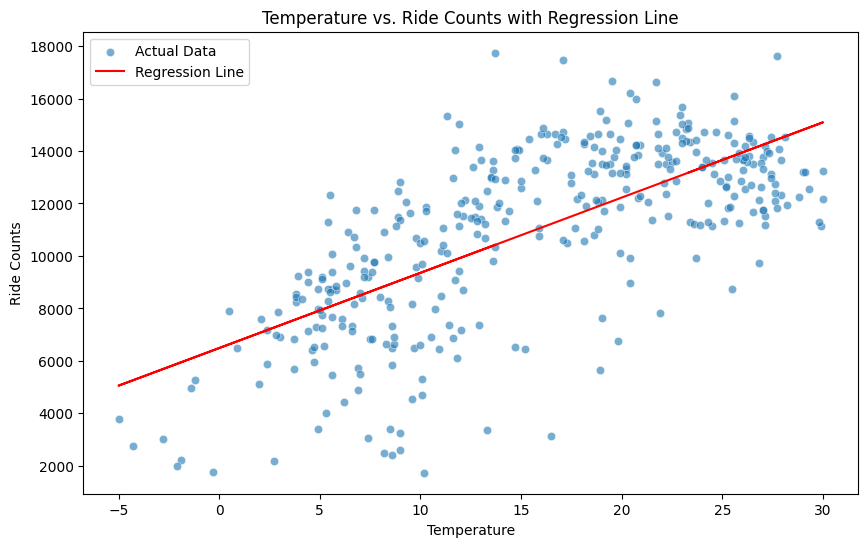

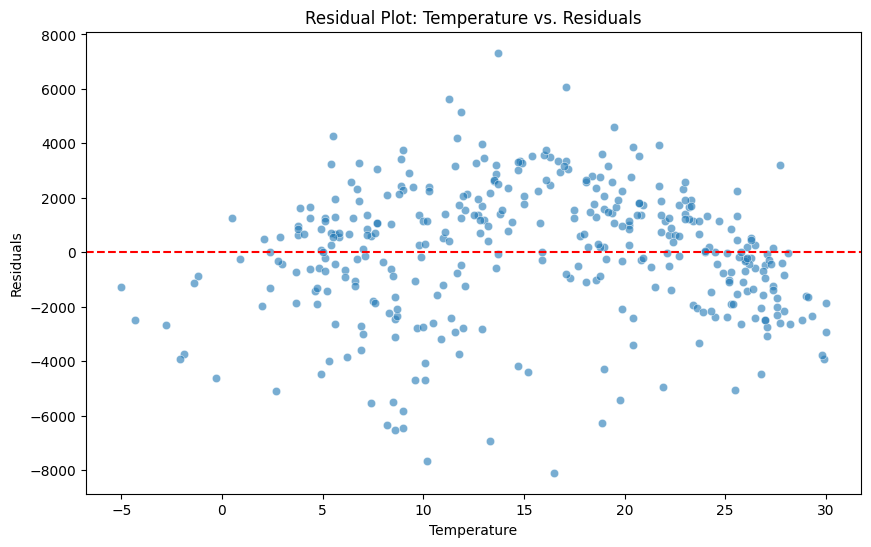

In [207]:
# Scatter plot with regression line
plt.figure(figsize=(10, 6))
sns.scatterplot(x='temp', y='rides_counts', data=rides_per_day, alpha=0.6, label='Actual Data')
plt.plot(rides_per_day['temp'], model0.predict(rides_per_day[['temp']]), color='red', label='Regression Line')
plt.xlabel("Temperature")
plt.ylabel("Ride Counts")
plt.title("Temperature vs. Ride Counts with Regression Line")
plt.legend()
plt.show()

# Residual plot
plt.figure(figsize=(10, 6))
residuals = rides_per_day['rides_counts'] - model0.predict(rides_per_day[['temp']])
sns.scatterplot(x=rides_per_day['temp'], y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Temperature")
plt.ylabel("Residuals")
plt.title("Residual Plot: Temperature vs. Residuals")
plt.show()

### Conclusion
The regression model indicates a significant positive relationship(p-value=5.98e-55) between temperature and ride count. Temperature is a significant predictor, explaining roughly 49% of the variation in ride counts. However, residual diagnostics suggest potential non-normality, which might warrant further investigation if precise predictive accuracy is required.

### Regression Analysis II
### Null and Alternative Hypotheses

- **Null Hypothesis (\( H_0 \))**: There is no correlation between temperature and duration. Mathematically, this implies that the slope (\( \beta \)) of `temp` in the regression model is zero.

  $
  H_0 : \beta_{\text{temp}} = 0
  $

- **Alternative Hypothesis (\( H_1 \))**: There is a correlation between temperature and duration, meaning the slope (\( \beta \)) of `temp` is not zero.

  $
  H_1 : \beta_{\text{temp}} \neq 0
  $

### Choose Significance Level

- **Significance Level $ (\alpha) $**: We’ll use a common significance level of 0.05. If the p-value for `temp` is below 0.05, we’ll reject the null hypothesis and conclude that temperature has a significant effect on duration.


In [ ]:
model1 = smf.ols("duration ~ temp", data=df).fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               duration   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     3242.
Date:                Mon, 04 Nov 2024   Prob (F-statistic):               0.00
Time:                        16:16:14   Log-Likelihood:            -3.9101e+07
No. Observations:             4009164   AIC:                         7.820e+07
Df Residuals:                 4009162   BIC:                         7.820e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    780.3645      5.177    150.743      0.000     770.218     790.511
temp          15.5736      0.274     56.940      0.000      15.037      16.110
================================================================================
Omnibus:                 21263392.892   Durbin-Watson:                     1.965
Prob(Omnibus):                  0.000   Jarque-Bera (JB):   2779991585425431.000
Skew:                         266.185   Prob(JB):                           0.00
Kurtosis:                  129005.092   Cond. No.                           47.2
================================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Conclusion
In this case, we reject the null hypothesis because the p-value for the temp coefficient is 0.000, which is below the typical significance level of 0.05. This means there is statistically significant evidence to suggest that temperature has an effect on duration.

However, while the effect is statistically significant, the practical significance is minimal due to the very low R-squared value (0.001), which indicates that temperature explains only 0.1% of the variation in duration. In other words, although temperature has a measurable effect on duration, it explains only a tiny fraction of its variance, so temperature alone is not a strong predictor of duration in this dataset. We need to pay attention for this discovery.

### Chi-squre Analysis
### Null and Alternative Hypotheses

- **Null Hypothesis ($ H_0 $)**: There is no association between `rideable_type` and `start_station_name`. In other words, the distribution of bike types (docked, classic, electric) is independent of the start station used by the user.

- **Alternative Hypothesis ($ H_1 $)**: There is an association between `rideable_type` and `start_station_name`. This implies that the choice of bike type varies depending on the start station used by the user.

### Step 2: Choose a Significance Level

- **Significance Level ($ \alpha $)**: We’ll use a commonly accepted significance level of 0.05. This means that we will reject the null hypothesis if the p-value is less than 0.05, suggesting a statistically significant association between `rideable_type` and `start_station_name`.


In [225]:
# convert the rideable_type and member_casual columns to string
df['rideable_type'] = df['rideable_type'].astype(str)
# df['member_casual'] = df['member_casual'].astype(str)
df['start_station_name']=df['start_station_name'].astype(str)
df = df.dropna(subset=['rideable_type', 'member_casual', 'start_station_name'])
# Create a contingency table
contingency_table = pd.crosstab(df['rideable_type'], df['start_station_name'])
contingency_table


start_station_name,10th & E St NW,10th & G St NW,10th & H St NE,10th & K St NW,10th & Monroe St NE,10th & Quincy St NE / Turkey Thicket Rec,10th & U St NW,10th St & Constitution Ave NW,10th St & Florida Ave NW,10th St & L'Enfant Plaza SW,...,Wisconsin Ave & Ingomar St NW,Wisconsin Ave & Newark St NW,Wisconsin Ave & O St NW,Wisconsin Ave & Rodman St NW,Wisconsin Ave & Upton St NW,Woodglen Dr & Executive Blvd,Woodley Park Metro / Calvert St & Connecticut Ave NW,Woodmont Ave & Strathmore St,Woody Ward Rec Center,Yuma St & Tenley Circle NW
rideable_type,,,,,,,,,,,,,,,,,,,,,
classic_bike,8614,5907,6987,9908,2616,1423,6371,10662,10513,5115,...,798,3888,9351,2451,474,513,7550,1864,52,634
docked_bike,448,139,0,303,46,15,52,743,13,655,...,12,47,231,19,0,48,168,69,0,0
electric_bike,2646,1986,2258,3051,1128,1326,2506,2098,4643,1517,...,329,3373,5731,1202,328,131,3775,533,24,355


In [216]:
from scipy.stats import chi2_contingency
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic:", chi2_stat)
print("P-Value:", p_value)
print("Degrees of Freedom:", dof)
print("Expected Frequencies:\n", expected)

Chi-Square Statistic: 305493.940601531
P-Value: 0.0
Degrees of Freedom: 1614
Expected Frequencies:
 [[8.37860762e+03 5.74794811e+03 6.61600850e+03 ... 1.76474602e+03
  5.43879552e+01 7.07759049e+02]
 [1.99530151e+02 1.36883001e+02 1.57555197e+02 ... 4.20260807e+01
  1.29520768e+00 1.68547420e+01]
 [3.12986222e+03 2.14716889e+03 2.47143631e+03 ... 6.59227899e+02
  2.03168371e+01 2.64386209e+02]]


In [ ]:
df['day'] = df['started_at'].dt.day_name()


0             Friday
1            Tuesday
2             Friday
3            Tuesday
4           Saturday
             ...    
4009159     Thursday
4009160      Tuesday
4009161      Tuesday
4009162     Saturday
4009163    Wednesday
Name: day, Length: 4009164, dtype: object

### Conclusion
The results suggest that the type of bike chosen (docked, classic, electric) is associated with the start station. In other words, `the distribution of bike types is not uniform across all start stations.`

This may imply that certain start stations have a higher tendency for specific bike types, possibly due to user preferences, station location, or operational policies regarding bike distribution.

### Anova Analysis
### Hypotheses for ANOVA $ (\alpha = 0.05) $

- **Null Hypothesis ($ H_0 $)**: There is no significant difference in the mean values of duration time across the days of the week (Monday, Tuesday, etc.). 

  $
  H_0: \mu_{\text{Monday}} = \mu_{\text{Tuesday}} = \mu_{\text{Wednesday}} = \mu_{\text{Thursday}} = \mu_{\text{Friday}} = \mu_{\text{Saturday}} = \mu_{\text{Sunday}}
  $

- **Alternative Hypothesis ($ H_1 $)**: At least one day of the week has a mean value of duration that is significantly different from the others.

  $
  H_1: \text{At least one } \mu_{\text{day}} \text{ differs from the others}
  $


In [226]:
model = smf.ols('duration ~ day', data=df).fit()
table = sm.stats.anova_lm(model, typ=1) # Type 1 ANOVA DataFrame
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               duration   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     685.6
Date:                Mon, 04 Nov 2024   Prob (F-statistic):               0.00
Time:                        17:27:12   Log-Likelihood:            -3.9100e+07
No. Observations:             4009164   AIC:                         7.820e+07
Df Residuals:                 4009157   BIC:                         7.820e+07
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         1018.8522      5.460    186.595      0.000    1008.150    1029.554
day[T.Monday]      -22.5525      7.921     -2.847      0.004     -38.077      -7.028
day[T.Saturday]    243.2261      7.666     31.728      0.000     228.201     258.251
day[T.Sunday]      231.9363      7.851     29.542      0.000     216.548     247.324
day[T.Thursday]    -86.0068      7.673    -11.210      0.000    -101.045     -70.969
day[T.Tuesday]     -65.3451      7.717     -8.467      0.000     -80.471     -50.219
day[T.Wednesday]   -76.4137      7.722     -9.895      0.000     -91.549     -61.279
================================================================================
Omnibus:                 21265164.596   Durbin-Watson:                     1.965
Prob(Omnibus):                  0.000   Jarque-Bera (JB):   2781965802383547.000
Skew:                         266.266   Prob(JB):                           0.00
Kurtosis:                  129050.889   Cond. No.                           7.82
================================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### ANOVA Results Summary

The ANOVA results indicate significant differences in `duration` across days of the week:

- **F-Statistic**: 685.6, with a p-value of 0.00, meaning we reject the null hypothesis. There is a significant effect of day on `duration`.

Weekends tend to have longer rides, possibly for recreation, while weekdays have shorter, utilitarian rides. However, the low R-squared (0.001) suggests day of the week explains very little of the total variation in `duration`.


In [231]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
res2 = pairwise_tukeyhsd(df['duration'], df['day'], alpha=0.05)
res2.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
Friday,Monday,-22.5525,0.0665,-45.9057,0.8007,False
Friday,Saturday,243.2261,0.0,220.6241,265.8281,True
Friday,Sunday,231.9363,0.0,208.7887,255.0838,True
Friday,Thursday,-86.0068,0.0,-108.628,-63.3857,True
Friday,Tuesday,-65.3451,0.0,-88.0987,-42.5915,True
Friday,Wednesday,-76.4137,0.0,-99.1809,-53.6465,True
Monday,Saturday,265.7786,0.0,242.586,288.9712,True
Monday,Sunday,254.4888,0.0,230.7642,278.2133,True
Monday,Thursday,-63.4543,0.0,-86.6656,-40.2431,True
Monday,Tuesday,-42.7926,0.0,-66.133,-19.4522,True


### Tukey HSD Results Summary

- **Significant Differences**: 
  - Weekends (Saturday and Sunday) have significantly longer durations than most weekdays.
  - Friday has longer durations than Monday through Thursday.

- **Non-Significant Differences**:
  - No significant difference between Saturday and Sunday.
  - Weekdays like Tuesday, Wednesday, and Thursday have similar durations.

**Conclusion**: Weekends generally have longer ride durations, with Friday also showing higher durations than most other weekdays.


## Graphical Analysis

In [ ]:

rides_per_day['weather'].value_counts().plot(kind='bar', color='skyblue')